# Baseline

## Общая инициализация
Нужно выполнить в самом начале независимо от дальнейших действий

### Путь к каталогу, в котором лежит датасет
датасет представлен файлом `train.csv` и папкой `train`

#### Инициализация путей 

In [5]:
import os.path as path

In [11]:
import zipfile

zip_path = r"W:\Jupyter\acoustic_events\improving_baseline\audio_train.zip"
extract_to = r"W:\Jupyter\acoustic_events\improving_baseline"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Готово! Содержимое папки:")
print(os.listdir(extract_to))

Готово! Содержимое папки:
['.ipynb_checkpoints', 'audio_train.zip', 'baseline.ipynb', 'train', 'train.csv']


In [15]:
base_folder = r"W:\Jupyter\acoustic_events\improving_baseline"

train_folder = path.join(base_folder, "train")
train_csv    = path.join(base_folder, "train.csv")
train_pickle = path.join(base_folder, "train.pickle")
labels_pickle = path.join(base_folder, "labels.pickle")

### Изучение аудиофайлов датасета

In [16]:
import os
import random

import librosa
import librosa.feature as F

import numpy as np
    
import matplotlib.pyplot as plt

from IPython.display import Audio

In [17]:
# random filename from dir
files = os.listdir(train_folder)
filename = random.choice(files)
filename

'ce4d3e6b59617b018b92.wav'

#### Спектрограмма

In [18]:
# spectrogram parameters
sample_rate = 11025

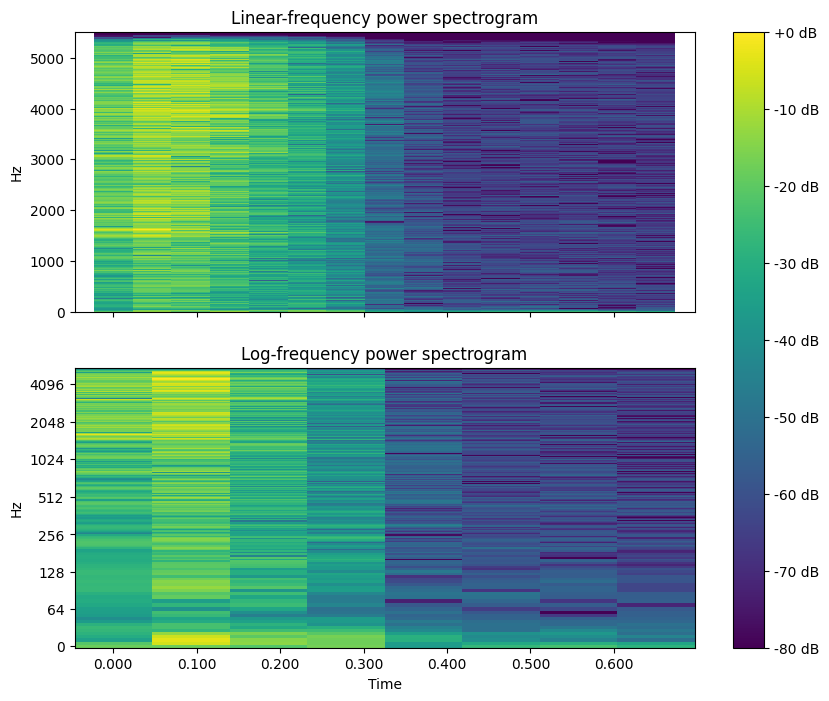

In [19]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

# draw linear-frequency spectrogram
hop_length = 512
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img1 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_top,
    x_axis='time',
    y_axis='linear',
    cmap=cmap,
)
ax_top.set(title='Linear-frequency power spectrogram')
ax_top.label_outer()

# draw log-frequency spectrogram
hop_length = 1024
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img2 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_bottom,
    x_axis='time',
    y_axis='log',
    cmap=cmap,
)
ax_bottom.set(title='Log-frequency power spectrogram')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

#### Mel-спектрограмма

In [20]:
# melspectrogram parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

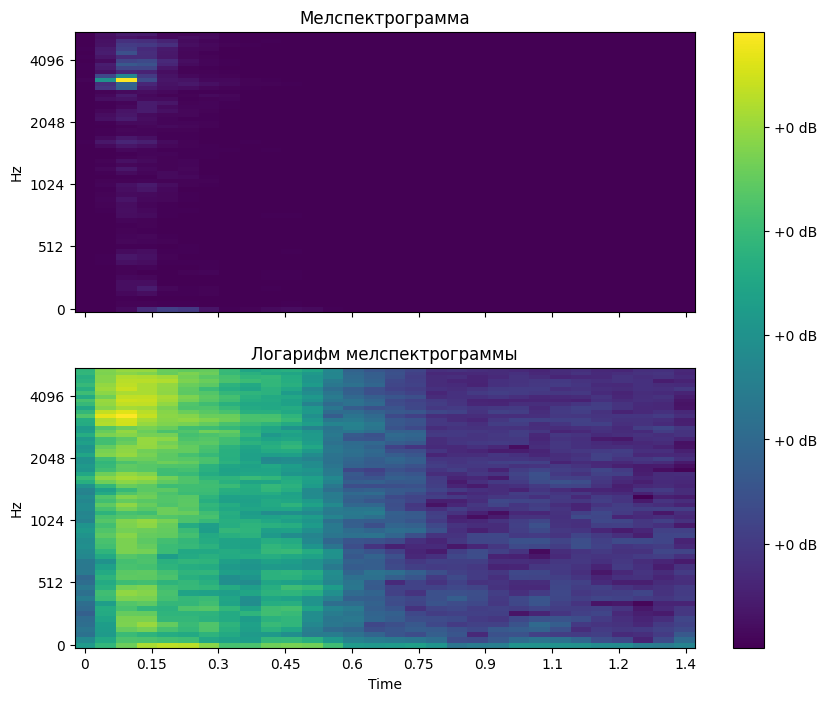

In [21]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

mel_spec = F.melspectrogram(
    y=wav_data,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels, 
    fmax=sample_rate // 2
)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

img1 = librosa.display.specshow(
    mel_spec,
    sr=sr,
    fmax=sr // 2,
    ax=ax_top,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_top.set(title='Мелспектрограмма')
ax_top.label_outer()

D = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(
    D,
    sr=sr,
    fmax=sr // 2,
    ax=ax_bottom,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_bottom.set(title='Логарифм мелспектрограммы')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

## Извлечение признаков

In [22]:
import os
import pickle
from enum import Enum
from typing import NoReturn, Optional

from tqdm import tqdm

import pandas as pd
import numpy as np

import librosa
import librosa.feature as F


class SetType(Enum):
    """Set type"""
    TRAIN = 1
    TEST  = 2
    DEV   = 3


def extract_log_mel_feats(set_type:SetType, path_to_csv:str, path_to_files:str,
                          out_path:str, labels_pickle:str, sr:Optional[int], n_fft:int,
                          hop_length:int, n_mels:int):
    """
    Extract features from given files and store them in binary format.

    :param set_type: set tyle
    :param path_to_csv: path to loaded csv
    :param path_to_files: path to loaded data
    :param out_path: path to store extracted features
    :param labels_pickle: path to store labels dictionary
    :param sr: input files sample rate
    :param n_fft: size of fft window
    :param hop_length: hop size
    :param n_mels: number of mel band

    :return:
    """
    if set_type not in [SetType.TRAIN, SetType.TEST]:
        raise Exception(f'Such set type not supported: {set_type}')

    feats = []

    if set_type == SetType.TRAIN:
        meta = pd.read_csv(path_to_csv, skiprows=1, names=['fname', 'label'])

        file_names = list(meta['fname'])
        n_files = len(file_names)
        labels = list(meta['label'])

        uniq_labels = np.sort(np.unique(labels))
        label_to_id = {label: i for i, label in enumerate(uniq_labels)}

        print('Total files:', n_files)

        for i, (file_name, label) in tqdm(enumerate(zip(file_names, labels))):
            wav_data, sr = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
            mel_spec = F.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
                'label_id': label_to_id[label]
            })

        pickle.dump(feats, open(out_path, 'wb'))
        pickle.dump(label_to_id, open(labels_pickle, 'wb'))
        return label_to_id
    else:
        for i, file_name in tqdm(enumerate(os.listdir(path_to_files))):
            wav_data, sr = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
            if len(wav_data) == 0:
                wav_data = np.zeros(sr)
            mel_spec = F.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
            })

        pickle.dump(feats, open(out_path, 'wb'))
        return

In [23]:
# feature extraction parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

In [24]:
# extract features and store to `train_pickle` extracted features
label_to_id = extract_log_mel_feats(
    SetType.TRAIN,
    train_csv, 
    train_folder, 
    train_pickle,
    labels_pickle,
    sample_rate, 
    n_fft, 
    hop_length, 
    n_mels
)

id_to_label = [label for label, i in label_to_id.items()]

Total files: 5683


5683it [01:11, 79.76it/s]


## Алгоритм детектирования

### Подготовительный этап

In [25]:
from typing import NoReturn
from pprint import pprint
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

In [26]:
device = device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [27]:
cpu_count = os.cpu_count()

num_workers = cpu_count if device == "cpu" else 0
num_workers, cpu_count

(0, 12)

#### Добиваемся максимальной воспроизводимости
Согласно данному мануалу: https://pytorch.org/docs/stable/notes/randomness.html

In [28]:
def set_random_state(random_state:int=0) -> NoReturn:
    """Initialize random generators.

    Parameters
    ==========
    random_state : int = 0
        Determines random number generation for centroid initialization.
        Use an int to make the randomness deterministic.
    """
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [29]:
random_state = 42

In [30]:
set_random_state(random_state)

In [31]:
torch.use_deterministic_algorithms(True)

In [32]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8
%env PYTHONHASHSEED=42

env: CUBLAS_WORKSPACE_CONFIG=:4096:8
env: PYTHONHASHSEED=42


### Архитектура нейронной сети

In [33]:
class DummyNetwork(nn.Module):
    """Neural network base architecture"""
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=64, kernel_size=5, stride=(2, 2), device=device)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3, stride=(1, 1), device=device)
        self.conv3 = nn.Conv2d(in_channels=96, out_channels=64, kernel_size=3, stride=(1, 1), device=device)

        self.mp = nn.MaxPool2d(kernel_size=(2, 2), stride=(1, 1))
        
        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)
        self.dropout3 = nn.Dropout(p=0.3)
        
        self.bn1 = nn.BatchNorm2d(num_features=64, device=device)
        self.bn2 = nn.BatchNorm2d(num_features=96, device=device)
        self.bn3 = nn.BatchNorm2d(num_features=64, device=device)

        self.flat = nn.Flatten()

        # 33856 - должно соответствовать форме self.flat
        self.fc1 = nn.Linear(33856, 41, device=device)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout3(x)

        x = self.flat(x)

        # здесь можно еще добавить полносвязный слой или слои
        x = self.fc1(x)

        return x

In [34]:
set_random_state(random_state) # try to run this cell several times
                               # then comment this line and run it several times again
                               # * pay attention at tensors values

# random 4D tensor
random_input = torch.randn(1, 1, 64, 64, requires_grad=True, device=device)

print(f"Исходный тензор {list(random_input.shape)}:")
pprint(random_input)

# create neural network instance
network = DummyNetwork()

# pass data throught the neural network
output = network(random_input)

print(f"\nТензор на выходе нейронной сети {list(output.shape)}:")
pprint(output)

Исходный тензор [1, 1, 64, 64]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.8146,  0.2502, -0.4273],
          [ 1.1044, -1.1028,  0.5543,  ..., -1.2072, -0.2438, -0.6784],
          [ 0.1973,  0.9782, -0.0287,  ..., -0.1266, -0.4321, -1.3943],
          ...,
          [-1.1998,  0.5818, -0.7198,  ..., -0.6079, -1.8145,  0.2807],
          [-0.0970,  0.9319, -0.4393,  ..., -0.1155, -0.0528,  1.1175],
          [ 3.0098,  1.3304, -1.1632,  ...,  0.1124,  0.2769, -1.2535]]]],
       device='cuda:0', requires_grad=True)

Тензор на выходе нейронной сети [1, 41]:
tensor([[ 0.4460,  0.5341,  1.0207,  0.2073, -0.1240,  0.8750,  0.3648, -0.3112,
          0.5579,  0.2430, -0.3420,  0.5798,  0.9219,  0.6956,  0.8216,  1.4519,
          0.6121, -0.1886, -0.2221, -0.3860,  1.4354, -0.3686, -0.4061,  1.3561,
          0.2685, -0.1416,  1.4081, -0.0590, -0.2047, -1.2422,  0.8342, -0.4554,
         -0.4401,  0.6899,  0.4783, -0.6975, -1.2489,  0.9157, -0.2990, -0.1210,
          0.2113]], device=

### Шаг оптимизации

In [35]:
import torch.optim as optim

In [36]:
set_random_state(random_state)


# choose loss function
criterion = nn.CrossEntropyLoss()

# choose and tune optimizer
optimizer = optim.SGD(network.parameters(), lr=0.001)
optimizer.zero_grad()

random_input = torch.randn(3, 1, 64, 64, requires_grad=True, device=device)
print(f"Тензор на входе сети {list(random_input.shape)}:")
pprint(random_input)

output = network(random_input)
print(f"\nТензор на выходе сети {list(output.shape)}:")
pprint(output)

target = torch.randint(5, (3,), dtype=torch.long, device=device)
print(f"\nТензор с целевыми значениями {list(target.shape)}:")
pprint(target)

loss = criterion(output, target)
print("\nЗначение функции потерь:", loss.item())

# backpropagation
loss.backward()

# next step
optimizer.step() 

Тензор на входе сети [3, 1, 64, 64]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.8146,  0.2502, -0.4273],
          [ 1.1044, -1.1028,  0.5543,  ..., -1.2072, -0.2438, -0.6784],
          [ 0.1973,  0.9782, -0.0287,  ..., -0.1266, -0.4321, -1.3943],
          ...,
          [-1.1998,  0.5818, -0.7198,  ..., -0.6079, -1.8145,  0.2807],
          [-0.0970,  0.9319, -0.4393,  ..., -0.1155, -0.0528,  1.1175],
          [ 3.0098,  1.3304, -1.1632,  ...,  0.1124,  0.2769, -1.2535]]],


        [[[ 1.1346, -0.6329, -0.9147,  ..., -1.5122, -1.1374,  0.7628],
          [ 0.9661, -0.0587, -0.2129,  ...,  1.2377,  0.5842,  1.6728],
          [ 0.7942,  0.3131, -0.3607,  ...,  0.1261, -0.1309,  2.0342],
          ...,
          [-0.3319,  0.8590,  0.7535,  ..., -1.2910, -0.3644,  0.9805],
          [-0.5130,  0.6719, -0.1551,  ..., -0.4551, -0.1417, -1.2772],
          [-0.4063,  0.0820,  0.8311,  ..., -1.0449,  1.5397, -2.0042]]],


        [[[-0.5852, -0.9346,  0.9684,  ...,  0.5966, -1.6748,

### Обучение нейронной сети

#### Загрузка ранее извлеченных признаков и подготовка данных для обучения

In [37]:
import pickle

In [38]:
train_data = pickle.load(open(train_pickle, "rb"))

label_to_id = pickle.load(open(labels_pickle, "rb"))
id_to_label = [label for label, i in label_to_id.items()]

In [39]:
def prepare_shape(feature):
    tmp = feature
    N = 64 # размер во времени (можно увеличить, должно стать лучше)
    while tmp.shape[1] < N:
        # можно попробовать сделать np.pad для коротких файлов, вместо повторения до необходимой длины
        tmp = np.hstack((tmp, tmp))
    # случайный сдвиг должен улучшить результат (для этого нужно функцию перенести в EventDetectionDataset)
    tmp = tmp[np.newaxis, :, :N]
    return tmp

In [40]:
# можно улучшить, используя сбалансированное валидационное множество
# гуглить stratified train test split sklearn
validation_set_size = 800

x_val = []
y_val = []

x_tr = []
y_tr = []

for i, row in enumerate(train_data):
    feature = prepare_shape(row['feature'])
    if i < validation_set_size:
        x_val.append(feature)
        y_val.append(row['label_id'])
    else:
        x_tr.append(feature)
        y_tr.append(row['label_id'])

x_val = np.asarray(x_val)
x_tr = np.asarray(x_tr)

y_val = np.asarray(y_val)
y_tr = np.asarray(y_tr)

print(f"""
Train set:
    x.shape: {x_tr.shape}
    y.shape: {y_tr.shape}

Validation set:
    x.shape: {x_val.shape}
    y.shape: {y_val.shape}
""")


Train set:
    x.shape: (4883, 1, 64, 64)
    y.shape: (4883,)

Validation set:
    x.shape: (800, 1, 64, 64)
    y.shape: (800,)



In [41]:
from torch.utils.data import Dataset

In [42]:
class EventDetectionDataset(Dataset):
    def __init__(self, x, y=None, device="cpu"):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # добавить сюда prepare_shape()
        if self.y is not None:
            return \
                torch.tensor(self.x[idx], device=device),\
                torch.tensor(self.y[idx], device=device)

        return torch.tensor(self.x[idx], device=device)

In [43]:
train_dset = EventDetectionDataset(x_tr, y_tr, device=device)
val_dset = EventDetectionDataset(x_val, y_val, device=device)

In [44]:
set_random_state(random_state)

sample_x, sample_y = random.choice(val_dset)

sample_y.item(), id_to_label[sample_y]

(10, np.str_('Cough'))

In [45]:
import librosa
import matplotlib.pyplot as plt

In [46]:
sample_rate = 11025

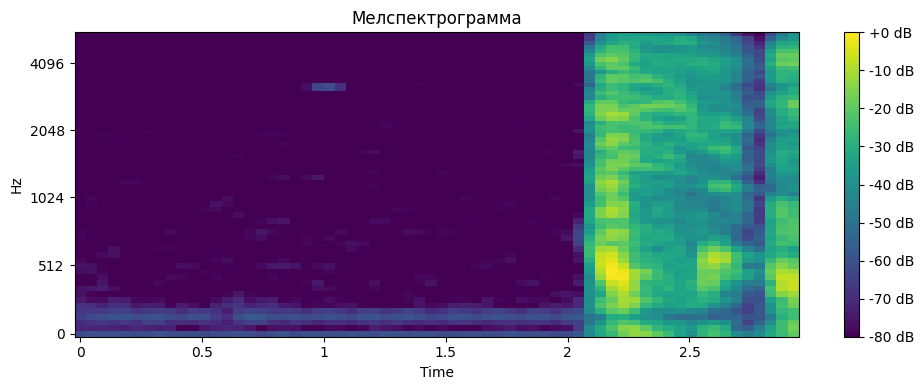

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
cmap = "viridis"

img = librosa.display.specshow(
    sample_x[0].numpy(force=True),
    sr=sample_rate,
    fmax=sample_rate // 2,
    ax=ax,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax.set(title='Мелспектрограмма')
ax.label_outer()

fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.tight_layout()
plt.show()

In [48]:
from torch.utils.data import DataLoader

In [49]:
train_loader = DataLoader(train_dset, batch_size=41, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dset, batch_size=41, shuffle=False, num_workers=num_workers)

In [50]:
import time
from sklearn.metrics import accuracy_score

In [51]:
start_time = time.time()

n_epoch = 50

set_random_state(random_state)

criterion = nn.CrossEntropyLoss()
network = DummyNetwork()

# можно попробовать другой optimizer, тоже считается улучшением
optimizer = optim.SGD(network.parameters(), lr=0.001)

train_loss = []
val_loss = []

train_acc = []
val_acc = []

for e in range(n_epoch):
    print(f'epoch #{e+1}')

    # train
    loss_list = []
    outputs = []
    targets = []
    for i_batch, sample_batched in enumerate(train_loader):
        x, y = sample_batched
        optimizer.zero_grad()

        output = network(x)
        outputs.append(output.argmax(axis=1))

        target = y
        targets.append(target)

        loss = criterion(output, target.long())
        loss_list.append(loss.item())
        loss.backward()
        optimizer.step()

    y_true = torch.hstack(targets).numpy(force=True)
    y_pred = torch.hstack(outputs).numpy(force=True)
    acc = accuracy_score(y_true, y_pred)

    train_loss.append(np.mean(loss_list))
    train_acc.append(acc)

    print(f'[train] mean loss: {train_loss[-1]}')
    print(f'[train] accuracy:  {acc}')

    loss_list = []
    outputs = []
    targets = []
    with torch.no_grad():
        for i_batch, sample_batched in enumerate(val_loader):
            x, y = sample_batched
            #optimizer.zero_grad()

            output = network(x)
            outputs.append(output.argmax(axis=1))

            target = y
            targets.append(target)

            loss = criterion(output, target.long())
            loss_list.append(loss.item())
            #loss.backward()
            #optimizer.step()

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        acc = accuracy_score(y_true, y_pred)

        val_loss.append(np.mean(loss_list))
        val_acc.append(acc)
        
        print(f'[val] mean loss:   {val_loss[-1]}')
        print(f'[val] accuracy:    {acc}', end="\n\n")

print(f"Execution time: {(time.time() - start_time):.2f} seconds")

epoch #1
[train] mean loss: 3.4949101070563
[train] accuracy:  0.12021298382142126
[val] mean loss:   5.949120736122131
[val] accuracy:    0.07375

epoch #2
[train] mean loss: 2.9451802730560304
[train] accuracy:  0.21236944501331148
[val] mean loss:   4.271702551841736
[val] accuracy:    0.1075

epoch #3
[train] mean loss: 2.674491347869237
[train] accuracy:  0.27687896784763466
[val] mean loss:   7.147215580940246
[val] accuracy:    0.03625

epoch #4
[train] mean loss: 2.5316436658302943
[train] accuracy:  0.32377636698750767
[val] mean loss:   4.409538602828979
[val] accuracy:    0.09875

epoch #5
[train] mean loss: 2.4004818300406137
[train] accuracy:  0.3458939176735613
[val] mean loss:   3.9742288827896117
[val] accuracy:    0.15

epoch #6
[train] mean loss: 2.266569463411967
[train] accuracy:  0.38091337292647964
[val] mean loss:   4.990056777000428
[val] accuracy:    0.1075

epoch #7
[train] mean loss: 2.180532817045848
[train] accuracy:  0.3991398730288757
[val] mean loss:   2

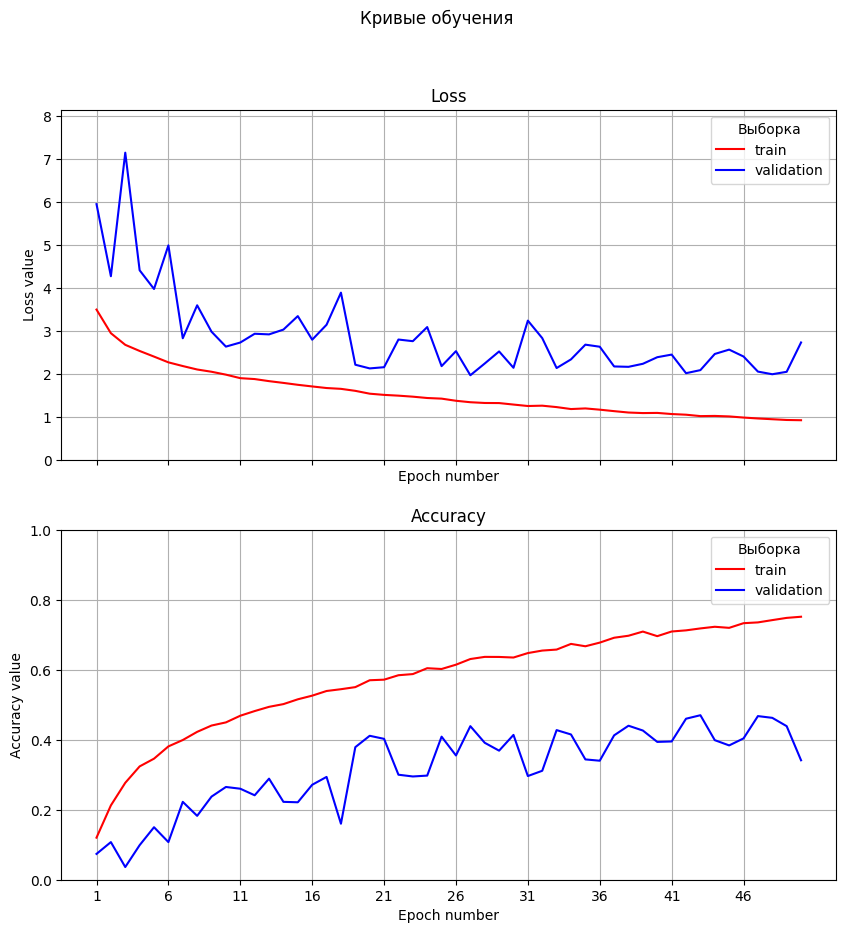

In [52]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

## Удваиваем частоту дискретизации и количество мел-фильтров при извлечении признаков:

In [62]:
import librosa
import librosa.feature

sample_rate_v2 = 22050
n_fft_v2 = 2048
hop_length_v2 = n_fft_v2 // 4
n_mels_v2 = 128

train_pickle_v2 = path.join(base_folder, "train_v2.pickle")
labels_pickle_v2 = path.join(base_folder, "labels_v2.pickle")


def extract_log_mel_feats_v2(path_to_csv, path_to_files, out_path, labels_pickle,
                              sr, n_fft, hop_length, n_mels):
    feats = []
    meta = pd.read_csv(path_to_csv, skiprows=1, names=['fname', 'label'])
    file_names = list(meta['fname'])
    labels = list(meta['label'])
    uniq_labels = np.sort(np.unique(labels))
    label_to_id = {label: i for i, label in enumerate(uniq_labels)}
    print('Total files:', len(file_names))

    for file_name, label in tqdm(zip(file_names, labels), total=len(file_names)):
        wav_data, sr_out = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
        mel_spec = librosa.feature.melspectrogram(
            y=wav_data,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmax=sr_out // 2
        )
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        feats.append({
            'fname': file_name,
            'feature': log_mel_spec,
            'label_id': label_to_id[label]
        })

    pickle.dump(feats, open(out_path, 'wb'))
    pickle.dump(label_to_id, open(labels_pickle, 'wb'))
    return label_to_id


label_to_id = extract_log_mel_feats_v2(
    train_csv,
    train_folder,
    train_pickle_v2,
    labels_pickle_v2,
    sample_rate_v2,
    n_fft_v2,
    hop_length_v2,
    n_mels_v2
)
id_to_label = [label for label, i in label_to_id.items()]

Total files: 5683


100%|██████████████████████████████████████████████████████████████████████████████| 5683/5683 [01:01<00:00, 92.51it/s]


## Stratified split

Сбалансируем валидационную выборку по классам:

In [67]:
from sklearn.model_selection import train_test_split

features = [row['feature'] for row in train_data]
labels   = [row['label_id'] for row in train_data]

x_tr, x_val, y_tr, y_val = train_test_split(
    features, labels,
    test_size=800,
    stratify=labels,
    random_state=random_state,
)
y_tr  = np.asarray(y_tr)
y_val = np.asarray(y_val)

print(f"Train: {len(x_tr)} | Val: {len(x_val)}")
print(f"Уникальных классов в val: {len(np.unique(y_val))}") 

Train: 4883 | Val: 800
Уникальных классов в val: 41


## Random crop в __getitem__

В методе prepare() добавим start = np.random.randint(0, tmp.shape[1] - self.N + 1) для train, чтобы каждую эпоху модель видела случайный фрагмент аудио, нормализуем mel шкалу, меняем размер окна:

In [69]:
class EventDetectionDatasetV3(Dataset):
    def __init__(self, x, y=None, N=96, train=True, device="cpu"):
        self.x = x
        self.y = y
        self.N = N
        self.train = train
        self.device = device

    def __len__(self):
        return len(self.x)

    def _prepare(self, feature):
        tmp = feature
        while tmp.shape[1] < self.N:
            tmp = np.hstack((tmp, tmp))
        if self.train and tmp.shape[1] > self.N:
            start = np.random.randint(0, tmp.shape[1] - self.N + 1)
        else:
            start = 0
        tmp = tmp[np.newaxis, :, start:start + self.N]
        tmp = (tmp + 40.0) / 40.0
        return tmp.astype(np.float32)

    def __getitem__(self, idx):
        feat = self._prepare(self.x[idx])
        if self.y is not None:
            return (torch.tensor(feat, device=self.device),
                    torch.tensor(self.y[idx], device=self.device))
        return torch.tensor(feat, device=self.device)


N_FRAMES = 96

train_dset_v3 = EventDetectionDatasetV3(x_tr,  y_tr,  N=N_FRAMES, train=True,  device=device)
val_dset_v3   = EventDetectionDatasetV3(x_val, y_val, N=N_FRAMES, train=False, device=device)

train_loader_v3 = DataLoader(train_dset_v3, batch_size=64, shuffle=True,  num_workers=num_workers)
val_loader_v3   = DataLoader(val_dset_v3,   batch_size=64, shuffle=False, num_workers=num_workers)

## Улучшение архитектуры:

1. Добавим четверный сверточный слой conv4

2. Увеличиваем число каналов в conv2 и conv3

3. Даунсэмплинг MaxPool со stride=2

4. Добавляем fc слой, dropout помогает снизить переобучение

In [72]:
class ImprovedNetworkV2(nn.Module):
    def __init__(self, n_classes=41):
        super().__init__()
        self.conv1 = nn.Conv2d(1,   64,  5, stride=2, padding=2, device=device)
        self.conv2 = nn.Conv2d(64,  128, 3, stride=1, padding=1, device=device)
        self.conv3 = nn.Conv2d(128, 128, 3, stride=1, padding=1, device=device)
        self.conv4 = nn.Conv2d(128, 256, 3, stride=1, padding=1, device=device)

        self.bn1 = nn.BatchNorm2d(64,  device=device)
        self.bn2 = nn.BatchNorm2d(128, device=device)
        self.bn3 = nn.BatchNorm2d(128, device=device)
        self.bn4 = nn.BatchNorm2d(256, device=device)

        self.mp = nn.MaxPool2d(2, stride=2)
        self.dropout = nn.Dropout(0.2)


        self.fc1 = nn.Linear(256, 256, device=device)
        self.dropout_fc = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, n_classes, device=device)

    def forward(self, x):
        x = self.mp(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        x = self.mp(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = self.mp(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = x.mean(dim=[2, 3])
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

## Обучаем с Adam, увеличиваем количество эпох

Также делаем learning rate адаптивным (CosineAnnealingLR) 

In [73]:
import time
from sklearn.metrics import accuracy_score

start_time = time.time()
n_epoch = 100

set_random_state(random_state)
criterion = nn.CrossEntropyLoss()
network = ImprovedNetworkV2()
optimizer = optim.Adam(network.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epoch)

train_loss, val_loss, train_acc, val_acc = [], [], [], []
best_val_acc = 0.0

for e in range(n_epoch):
    network.train()
    loss_list, outputs, targets = [], [], []
    for x, y in train_loader_v3:
        optimizer.zero_grad()
        output = network(x)
        loss = criterion(output, y.long())
        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
        outputs.append(output.argmax(axis=1))
        targets.append(y)
    tr_acc = accuracy_score(torch.hstack(targets).numpy(force=True),
                            torch.hstack(outputs).numpy(force=True))
    train_loss.append(np.mean(loss_list)); train_acc.append(tr_acc)

    network.eval()
    loss_list, outputs, targets = [], [], []
    with torch.no_grad():
        for x, y in val_loader_v3:
            output = network(x)
            loss_list.append(criterion(output, y.long()).item())
            outputs.append(output.argmax(axis=1))
            targets.append(y)
    v_acc = accuracy_score(torch.hstack(targets).numpy(force=True),
                           torch.hstack(outputs).numpy(force=True))
    val_loss.append(np.mean(loss_list)); val_acc.append(v_acc)

    scheduler.step()

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(network.state_dict(), path.join(base_folder, "best_model.pt"))

    print(f'epoch #{e+1}: [train] loss {train_loss[-1]:.4f} acc {tr_acc:.4f} | '
          f'[val] loss {val_loss[-1]:.4f} acc {v_acc:.4f}')

print(f"\nExecution time: {(time.time() - start_time):.2f} sec")
print(f"Best val accuracy: {best_val_acc:.4f}")

epoch #1: [train] loss 3.1150 acc 0.1294 | [val] loss 2.8653 acc 0.1625
epoch #2: [train] loss 2.6867 acc 0.2275 | [val] loss 2.4801 acc 0.2900
epoch #3: [train] loss 2.4664 acc 0.2898 | [val] loss 2.2399 acc 0.3475
epoch #4: [train] loss 2.2089 acc 0.3492 | [val] loss 2.1056 acc 0.3875
epoch #5: [train] loss 2.0792 acc 0.4022 | [val] loss 1.9726 acc 0.4225
epoch #6: [train] loss 1.9552 acc 0.4311 | [val] loss 1.9084 acc 0.4500
epoch #7: [train] loss 1.8230 acc 0.4735 | [val] loss 1.7630 acc 0.5062
epoch #8: [train] loss 1.7568 acc 0.4909 | [val] loss 1.7521 acc 0.5062
epoch #9: [train] loss 1.6604 acc 0.5124 | [val] loss 1.6435 acc 0.5437
epoch #10: [train] loss 1.6011 acc 0.5380 | [val] loss 1.6845 acc 0.5212
epoch #11: [train] loss 1.5680 acc 0.5445 | [val] loss 1.5870 acc 0.5550
epoch #12: [train] loss 1.5211 acc 0.5597 | [val] loss 1.5755 acc 0.5587
epoch #13: [train] loss 1.4428 acc 0.5765 | [val] loss 1.6177 acc 0.5487
epoch #14: [train] loss 1.4160 acc 0.5968 | [val] loss 1.513

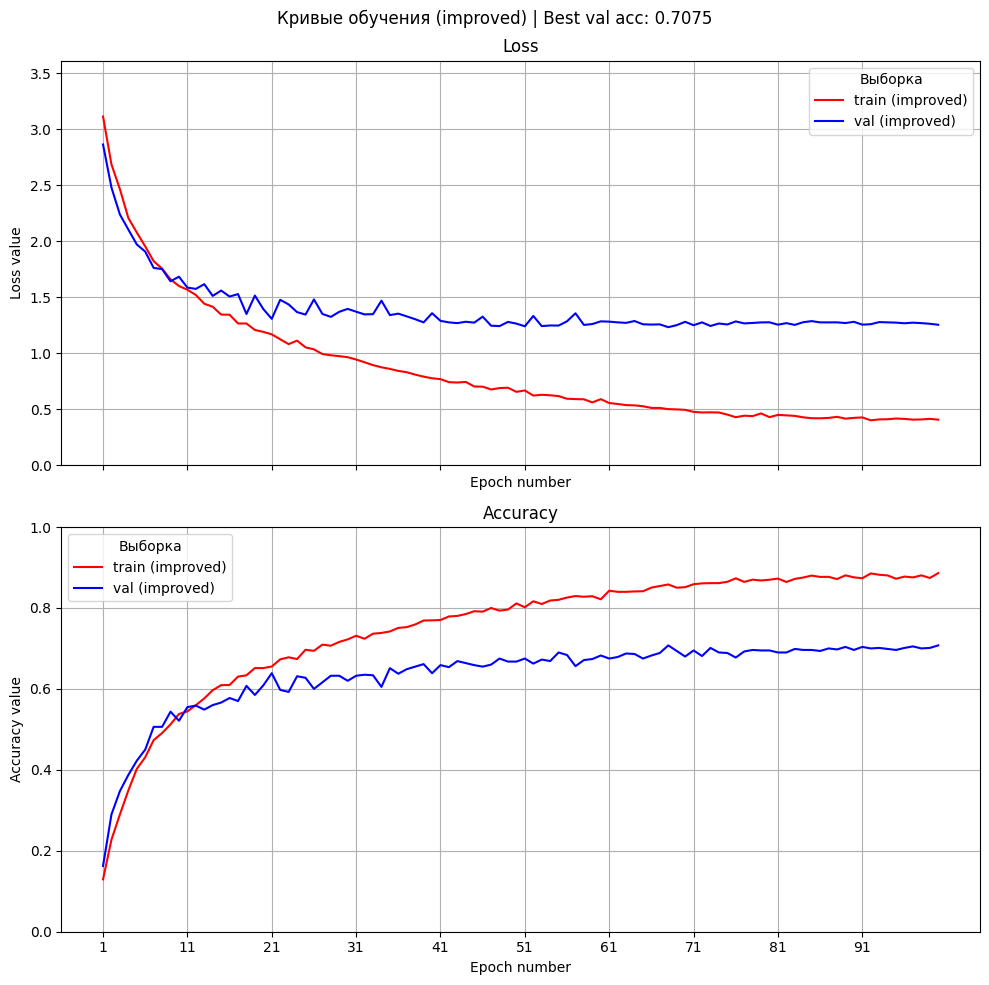

In [76]:
epochs_new = range(1, len(train_loss) + 1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)
xticks = range(1, len(train_loss) + 1, max(1, len(train_loss) // 10))

ax_top.plot(epochs_new, train_loss, 'r',  label='train (improved)')
ax_top.plot(epochs_new, val_loss,   'b',  label='val (improved)')
ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 0.5],
)
ax_top.legend(title="Выборка")
ax_top.grid()

ax_bottom.plot(epochs_new, train_acc, 'r',  label='train (improved)')
ax_bottom.plot(epochs_new, val_acc,   'b',  label='val (improved)')


ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(title="Выборка")
ax_bottom.grid()

fig.suptitle(f"Кривые обучения (improved) | Best val acc: {max(val_acc):.4f}")
plt.tight_layout()
plt.show()

## Выводы

В результате получили хорошее улучшение +0.31 accuracy. Это произошло благодаря:

1. Добавили больше частот sr 22050 + 128 мелов, что разнообразило информацию
2. random crop - бесплатная аугментация данных
3. Adam, scheduler сделал обучение более плавным, что видно на графиках
4. Также помогли ахритектурные изменения нейросети, добавление слоев, увеличение количества эпох обучения. Dropout помогает снизить переобучение. Как показали более ранние эксперименты, без работы над данными архитектура не дает существенных улучшений.